In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import xlrd

inputfile = '../data/original_data.xls'   # 数据文件
data = pd.read_excel(inputfile)  # 读取数据

In [2]:
data

,热水器编号,发生时间,开关机状态,加热中,保温中,有无水流,实际温度,热水量,水流量,节能模式,加热剩余时间,当前设置温度
0,R_00001,20141019063917,关,关,关,无,30°C,0%,0,关,0分钟,50°C
1,R_00001,20141019070154,关,关,关,无,30°C,0%,0,关,0分钟,50°C
2,R_00001,20141019070156,关,关,关,无,30°C,0%,8,关,0分钟,50°C
3,R_00001,20141019071230,关,关,关,无,30°C,0%,0,关,0分钟,50°C
4,R_00001,20141019071236,关,关,关,无,29°C,0%,0,关,0分钟,50°C
...,...,...,...,...,...,...,...,...,...,...,...,...
18835,R_00001,20141110231842,开,关,开,无,50°C,50%,0,关,0分钟,50°C
18836,R_00001,20141110231900,开,关,开,无,49°C,50%,0,关,0分钟,50°C
18837,R_00001,20141110231906,开,关,开,无,50°C,50%,0,关,0分钟,50°C
18838,R_00001,20141110231954,开,关,开,无,49°C,50%,0,关,0分钟,50°C


In [3]:
# 数据提取
# 提取属性“有无水流”中的值为“无"的数据
lv_non = data[data['有无水流'] == '无']

# 提取属性"有无水流"中的值为"有"的数据  
lv_move = data[data['有无水流'] == '有']

print("无水流数据量:", len(lv_non))
print("有水流数据量:", len(lv_move))

无水流数据量: 11422
有水流数据量: 7418


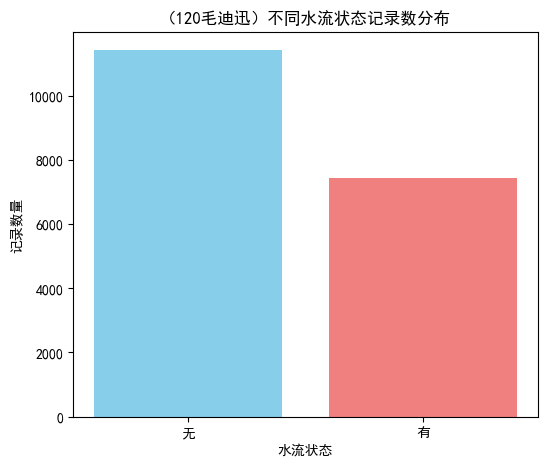

In [4]:
# 绘制条形图
fig = plt.figure(figsize = (6 ,5))  # 设置画布大小
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文显示字体
plt.rcParams['axes.unicode_minus'] = False 

# 计算不同水流状态的记录数
water_flow_counts = data['有无水流'].value_counts()

plt.bar(water_flow_counts.index, water_flow_counts.values, color=['skyblue', 'lightcoral'])

plt.xticks(rotation=0)  # 设置x刻度
plt.xlabel('水流状态')  # 设置x轴标签
plt.ylabel('记录数量')  # 设置y轴标签
plt.title('（120毛迪迅）不同水流状态记录数分布')  # 设置图像标题
plt.show()
plt.close()

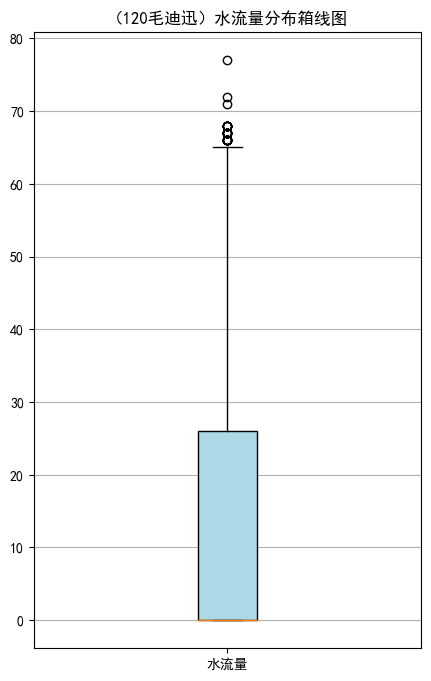

In [5]:
# 查看水流量分布
# 提取数据中“水流量”这一属性的数据，赋值为water
water = data['水流量']

# 绘制水流量分布箱型图
fig = plt.figure(figsize = (5 ,8))
plt.boxplot(water, patch_artist=True, boxprops=dict(facecolor='lightblue'), 
            labels=['水流量'])  # 画箱形图  设置填充颜色为淡蓝，设置x轴标签为‘水流量’
plt.title('（120毛迪迅）水流量分布箱线图')  # 设置标题'水流量分布箱线图'

plt.grid(axis='y')  # 显示y坐标轴的栅格
plt.show()

In [6]:
import numpy as np
data = pd.read_excel('../data/original_data.xls')
print('初始状态的数据形状为：', data.shape)

初始状态的数据形状为： (18840, 12)


In [7]:
data# 删除热水器编号、有无水流、节能模式属性
data = data.drop(['热水器编号', '有无水流', '节能模式'], axis=1)
print('删除冗余属性后的数据形状为：', data.shape)
data.to_csv('../tmp/water_heart.csv', index=False)  #将数据写入文件：tmp/water_heart.csv 中

删除冗余属性后的数据形状为： (18840, 9)


In [8]:
data.head()

,发生时间,开关机状态,加热中,保温中,实际温度,热水量,水流量,加热剩余时间,当前设置温度
0,20141019063917,关,关,关,30°C,0%,0,0分钟,50°C
1,20141019070154,关,关,关,30°C,0%,0,0分钟,50°C
2,20141019070156,关,关,关,30°C,0%,8,0分钟,50°C
3,20141019071230,关,关,关,30°C,0%,0,0分钟,50°C
4,20141019071236,关,关,关,29°C,0%,0,0分钟,50°C


In [9]:
# 读取数据
data = pd.read_csv('../tmp/water_heart.csv')

In [10]:
# 划分用水事件
threshold = pd.Timedelta('4 minutes')  # 阈值为4分钟
data['发生时间'] = pd.to_datetime(data['发生时间'], format='%Y%m%d%H%M%S')  # 转换时间格式

# 记录原始索引位置（从1开始）
data['原始行号'] = data.index + 1

# 只要流量大于0的记录
data_flow = data[data['水流量'] > 0].copy()
data_flow.reset_index(drop=True, inplace=True)

# 识别用水事件的开始和结束
sjKs = data_flow['发生时间'].diff() > threshold  # 相邻时间向前差分，比较是否大于阈值
sjKs.iloc[0] = True  # 令第一个时间为第一个用水事件的开始事件
sjJs = sjKs.iloc[1:]  # 向后差分的结果
sjJs = pd.concat([sjJs, pd.Series([True])])  # 令最后一个时间作为最后一个用水事件的结束时间

# 创建用水事件编号
data_flow['事件编号'] = sjKs.cumsum()  # 累积求和生成事件编号

print(f'共划分出 {data_flow["事件编号"].nunique()} 个用水事件')

# 创建数据框，并定义用水事件序列
sj = pd.DataFrame(np.arange(1, data_flow['事件编号'].max() + 1), columns=["事件序号"])  # 创建数据框

# 获取每个事件组的原始行索引
grouped = data_flow.groupby("事件编号")
sj["事件起始编号"] = grouped.apply(lambda x: x['原始行号'].iloc[0]).values
sj["事件终止编号"] = grouped.apply(lambda x: x['原始行号'].iloc[-1]).values

print('当阈值为4分钟的时候事件数目为：', sj.shape[0])

sj.to_csv('../tmp/sj.csv', index=False)  # 将结果写入文件"tmp/sj.csv"
print('用水事件划分结果已保存到 ../tmp/sj.csv')

共划分出 172 个用水事件
当阈值为4分钟的时候事件数目为： 172
用水事件划分结果已保存到 ../tmp/sj.csv


In [11]:
# 确定单次用水事件时长阈值
n = 4  # 使用以后四个点的平均斜率
threshold = pd.Timedelta(minutes=4)  # 专家阈值
data['发生时间'] = pd.to_datetime(data['发生时间'], format='%Y%m%d%H%M%S')  # 转换时间格式
data = data[data['水流量'] > 0]  # 只要流量大于0的记录

# 自定义函数：输入划分时间的时间阈值，得到划分的事件数
def event_num(ts):
    d = data['发生时间'].diff() > ts  # 相邻时间作差分，比较是否大于阈值
    return d.sum() + 1  # 这样直接返回事件数

dt = [pd.Timedelta(minutes=i) for i in np.arange(1, 9, 0.25)]
h = pd.DataFrame(dt, columns=['阈值'])  # 转换数据框，定义阈值列
h

,阈值
0,0 days 00:01:00
1,0 days 00:01:15
2,0 days 00:01:30
3,0 days 00:01:45
4,0 days 00:02:00
5,0 days 00:02:15
6,0 days 00:02:30
7,0 days 00:02:45
8,0 days 00:03:00
9,0 days 00:03:15


In [12]:
h['事件数'] = h['阈值'].apply(event_num)  # 计算每个阈值对应的事件数
h

,阈值,事件数
0,0 days 00:01:00,232
1,0 days 00:01:15,227
2,0 days 00:01:30,218
3,0 days 00:01:45,207
4,0 days 00:02:00,201
5,0 days 00:02:15,197
6,0 days 00:02:30,194
7,0 days 00:02:45,191
8,0 days 00:03:00,186
9,0 days 00:03:15,181


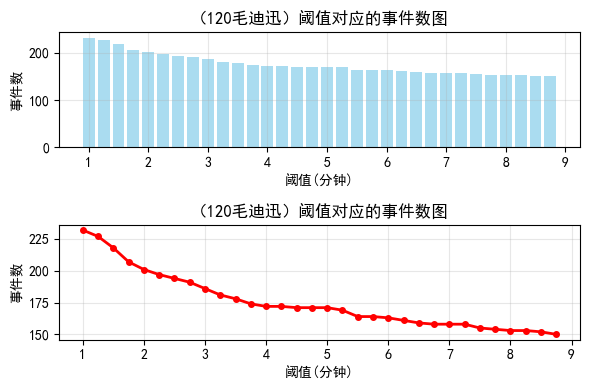

In [13]:
##### 画出阈值对应的事件数的折线图  即统计用水停顿的时间间隔并做频率分布表--参考代码
plt.rcParams['font.sans-serif'] = 'SimHei'  # 显示中文
plt.rcParams['axes.unicode_minus'] = False  # 显示负号

plt.figure(figsize=(6,4))  # 创建画布
ax1=plt.subplot(211)# 创建子图1
ax1.bar(h['阈值'].dt.total_seconds()/60, h['事件数'], width=0.2, color='skyblue', alpha=0.7)  # 绘制柱状图
plt.title('（120毛迪迅）阈值对应的事件数图')  # 标题
plt.xlabel('阈值(分钟)')  # x轴标签
plt.ylabel('事件数')  # y轴标签
plt.grid(True, alpha=0.3)

ax2=plt.subplot(212)  # 创建子图2
ax2.plot(h['阈值'].dt.total_seconds()/60, h['事件数'], 'ro-', markersize=4, linewidth=2)  # 绘制曲线
plt.title('（120毛迪迅）阈值对应的事件数图')  # 标题
plt.xlabel('阈值(分钟)')  # x轴标签
plt.ylabel('事件数')  # y轴标签
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()  # 显示图形

In [14]:
h['斜率'] = h['事件数'].diff() / 0.25  # 计算斜率
h['斜率指标'] = -h['斜率'].rolling(n).mean()  # 计算往后n个点的平均斜率
h

,阈值,事件数,斜率,斜率指标
0,0 days 00:01:00,232,NaN,NaN
1,0 days 00:01:15,227,-20.0,NaN
2,0 days 00:01:30,218,-36.0,NaN
3,0 days 00:01:45,207,-44.0,NaN
4,0 days 00:02:00,201,-24.0,31.0
5,0 days 00:02:15,197,-16.0,30.0
6,0 days 00:02:30,194,-12.0,24.0
7,0 days 00:02:45,191,-12.0,16.0
8,0 days 00:03:00,186,-20.0,15.0
9,0 days 00:03:15,181,-20.0,16.0


In [15]:
ts_index = 12  
ts = h.loc[ts_index, '阈值']
ts

Timedelta('0 days 00:04:00')

In [16]:
if ts > threshold:
    ts = threshold  # 如果计算值大于专家阈值，使用专家阈值
else:
    ts = threshold  # 无论计算值如何，都使用专家阈值
print('计算出的单次用水时长的阈值为：', ts)

计算出的单次用水时长的阈值为： 0 days 00:04:00


In [17]:
data = pd.read_excel('../data/water_hearter.xlsx',engine='openpyxl')  # 读取热水器使用数据记录
sj = pd.read_csv('../tmp/sj.csv')  # 读取用水事件记录
# 转换时间格式
data["发生时间"] = pd.to_datetime(data["发生时间"],format="%Y%m%d%H%M%S")
sj.head()

,事件序号,事件起始编号,事件终止编号
0,1,3,3
1,2,57,57
2,3,382,385
3,4,405,405
4,5,408,408


In [18]:
# 构建时间特征
timeDel = pd.Timedelta('0 days 00:00:02')  # 发送阈值，设为2秒

# 修正索引访问：事件起始编号和事件终止编号需要减1，因为data索引从0开始
sj["事件开始时间"] = data.loc[sj["事件起始编号"] - 1, "发生时间"].values - timeDel/2
sj["事件结束时间"] = data.loc[sj["事件终止编号"] - 1, "发生时间"].values + timeDel/2
sj['洗浴时间点'] = sj["事件开始时间"].dt.hour  # 用水开始时间的小时作为洗浴时间点
sj["总用水时长"] = (sj["事件结束时间"] - sj["事件开始时间"]).dt.total_seconds()  # 转换为秒数

sj.head()

,事件序号,事件起始编号,事件终止编号,事件开始时间,事件结束时间,洗浴时间点,总用水时长
0,1,3,3,2014-10-19 07:01:55,2014-10-19 07:01:57,7,2.0
1,2,57,57,2014-10-19 07:38:15,2014-10-19 07:38:17,7,2.0
2,3,382,385,2014-10-19 09:46:37,2014-10-19 09:47:16,9,39.0
3,4,405,405,2014-10-19 11:50:16,2014-10-19 11:50:18,11,2.0
4,5,408,408,2014-10-19 13:56:20,2014-10-19 13:56:22,13,2.0


In [19]:
# 停顿开始时间指从有水流到无水流，停顿结束时间指从无水流到有水流
for i in range(len(data)-1):
    if (data.loc[i,"水流量"] != 0) & (data.loc[i + 1,"水流量"] == 0) :
        data.loc[i + 1,"停顿开始时间"] = data.loc[i +1, "发生时间"] - timeDel
    if (data.loc[i,"水流量"] == 0) & (data.loc[i + 1,"水流量"] != 0) :
        data.loc[i,"停顿结束时间"] = data.loc[i , "发生时间"] + timeDel
        
# 提取停顿开始时间与结束时间所对应行号，放在数据框Stop中
indStopStart = data.index[data["停顿开始时间"].notnull()]+1
indStopEnd = data.index[data["停顿结束时间"].notnull()]+1
Stop = pd.DataFrame(data={"停顿开始编号":indStopStart[:-1],
                             "停顿结束编号":indStopEnd[1:]}) 

# 计算停顿时长，并放在数据框stop中，停顿时长=停顿结束时间-停顿结束时间
Stop["停顿时长"] = np.int64(data.loc[indStopEnd[1:]-1,"停顿结束时间"].values-
                      data.loc[indStopStart[:-1]-1,"停顿开始时间"].values)/1000000000
# 将每次停顿与事件匹配,停顿的开始时间要大于事件的开始时间，
# 且停顿的结束时间要小于事件的结束时间
for i in range(len(sj)):
    Stop.loc[(Stop["停顿开始编号"] > sj.loc[i,"事件起始编号"]) & 
           (Stop["停顿结束编号"] < sj.loc[i,"事件终止编号"]),"停顿归属事件"]=i+1
             
# 删除停顿次数为0的事件
Stop = Stop[Stop["停顿归属事件"].notnull()]
Stop.head()

,停顿开始编号,停顿结束编号,停顿时长,停顿归属事件
2,384,384,4.0,3.0
6,453,454,14.0,6.0
9,667,667,4.0,8.0
10,764,765,85.0,8.0
13,1063,1064,57.0,10.0


In [20]:
# 用水时长，用水/总时长
stopAgg =  Stop.groupby("停顿归属事件").agg({"停顿时长":sum,"停顿开始编号":len})
sj.loc[stopAgg.index - 1,"总停顿时长"] = stopAgg.loc[:,"停顿时长"].values
sj.loc[stopAgg.index-1,"停顿次数"] = stopAgg.loc[:,"停顿开始编号"].values
sj.fillna(0,inplace=True)  # 对缺失值用0插补
stopNo0 = sj["停顿次数"] != 0  # 判断用水事件是否存在停顿
sj.loc[stopNo0,"平均停顿时长"] = sj.loc[stopNo0,"总停顿时长"]/sj.loc[stopNo0,"停顿次数"] 
sj.fillna(0,inplace=True)  # 对缺失值用0插补
sj["用水时长"] = sj["总用水时长"] - sj["总停顿时长"]                        # 定义特征用水时长
sj["用水/总时长"] = sj["用水时长"] / sj["总用水时长"]                        # 定义特征 用水/总时长
print('用水事件用水时长与频率特征构造完成后数据的特征为：\n',sj.columns)
print('用水事件用水时长与频率特征构造完成后数据的前5行5列特征为：\n',
      sj.iloc[:5,:5])

用水事件用水时长与频率特征构造完成后数据的特征为：
 Index(['事件序号', '事件起始编号', '事件终止编号', '事件开始时间', '事件结束时间', '洗浴时间点', '总用水时长',
       '总停顿时长', '停顿次数', '平均停顿时长', '用水时长', '用水/总时长'],
      dtype='object')
用水事件用水时长与频率特征构造完成后数据的前5行5列特征为：
    事件序号  事件起始编号  事件终止编号              事件开始时间              事件结束时间
0     1       3       3 2014-10-19 07:01:55 2014-10-19 07:01:57
1     2      57      57 2014-10-19 07:38:15 2014-10-19 07:38:17
2     3     382     385 2014-10-19 09:46:37 2014-10-19 09:47:16
3     4     405     405 2014-10-19 11:50:16 2014-10-19 11:50:18
4     5     408     408 2014-10-19 13:56:20 2014-10-19 13:56:22


In [21]:
# 构造用水量属性
data["水流量"] = data["水流量"] / 60  # 原单位L/min，现转换为L/sec
sj["总用水量"] = 0 # 给总用水量赋一个初始值0

for i in range(len(sj)):
    Start = sj.loc[i,"事件起始编号"]-1
    End = sj.loc[i,"事件终止编号"]-1
    
    if Start != End:
        # 计算中间时间段的用水量
        for j in range(Start,End):
            if data.loc[j,"水流量"] != 0:
                # 使用实际时间间隔计算用水量
                time_interval = (data.loc[j+1, "发生时间"] - data.loc[j, "发生时间"]).total_seconds()
                sj.loc[i,"总用水量"] = sj.loc[i,"总用水量"] + data.loc[j,"水流量"] * time_interval
                
        # 加上最后一个时间点的用水量（使用2秒间隔）
        sj.loc[i,"总用水量"] = sj.loc[i,"总用水量"] + data.loc[End,"水流量"] * 2
    else:
        # 单点事件的用水量（使用2秒间隔）
        sj.loc[i,"总用水量"] = data.loc[Start,"水流量"] * 2

# 计算平均水流量s
sj["平均水流量"] = 0
valid_mask = sj["用水时长"] > 0
sj.loc[valid_mask, "平均水流量"] = sj.loc[valid_mask, "总用水量"] / sj.loc[valid_mask, "用水时长"]

sj.head()

,事件序号,事件起始编号,事件终止编号,事件开始时间,事件结束时间,洗浴时间点,总用水时长,总停顿时长,停顿次数,平均停顿时长,用水时长,用水/总时长,总用水量,平均水流量
0,1,3,3,2014-10-19 07:01:55,2014-10-19 07:01:57,7,2.0,0.0,0.0,0.0,2.0,1.000000,0.266667,0.133333
1,2,57,57,2014-10-19 07:38:15,2014-10-19 07:38:17,7,2.0,0.0,0.0,0.0,2.0,1.000000,0.266667,0.133333
2,3,382,385,2014-10-19 09:46:37,2014-10-19 09:47:16,9,39.0,4.0,1.0,4.0,35.0,0.897436,5.100000,0.145714
3,4,405,405,2014-10-19 11:50:16,2014-10-19 11:50:18,11,2.0,0.0,0.0,0.0,2.0,1.000000,0.733333,0.366667
4,5,408,408,2014-10-19 13:56:20,2014-10-19 13:56:22,13,2.0,0.0,0.0,0.0,2.0,1.000000,0.266667,0.133333


In [22]:
# 水流量波动=∑(((单次水流的值-平均水流量)^2)*持续时间)/用水时长
sj["水流量波动"] = 0 # 给水流量波动赋一个初始值0
for i in range(len(sj)):
    Start = sj.loc[i,"事件起始编号"] - 1
    End = sj.loc[i,"事件终止编号"] - 1
    for j in range(Start,End + 1):
        if data.loc[j,"水流量"] != 0:
            slbd = (data.loc[j,"水流量"] - sj.loc[i,"平均水流量"])**2
            slsj = (data.loc[j + 1,"发生时间"] - data.loc[j,"发生时间"]).seconds 
            sj.loc[i,"水流量波动"] = slbd * slsj + sj.loc[i,"水流量波动"] 
    sj.loc[i,"水流量波动"] = sj.loc[i,"水流量波动"] / sj.loc[i,"用水时长"]            
sj.head()

,事件序号,事件起始编号,事件终止编号,事件开始时间,事件结束时间,洗浴时间点,总用水时长,总停顿时长,停顿次数,平均停顿时长,用水时长,用水/总时长,总用水量,平均水流量,水流量波动
0,1,3,3,2014-10-19 07:01:55,2014-10-19 07:01:57,7,2.0,0.0,0.0,0.0,2.0,1.000000,0.266667,0.133333,0.00000
1,2,57,57,2014-10-19 07:38:15,2014-10-19 07:38:17,7,2.0,0.0,0.0,0.0,2.0,1.000000,0.266667,0.133333,0.00000
2,3,382,385,2014-10-19 09:46:37,2014-10-19 09:47:16,9,39.0,4.0,1.0,4.0,35.0,0.897436,5.100000,0.145714,5.28155
3,4,405,405,2014-10-19 11:50:16,2014-10-19 11:50:18,11,2.0,0.0,0.0,0.0,2.0,1.000000,0.733333,0.366667,0.00000
4,5,408,408,2014-10-19 13:56:20,2014-10-19 13:56:22,13,2.0,0.0,0.0,0.0,2.0,1.000000,0.266667,0.133333,0.00000


In [23]:
# 构造特征：停顿时长波动
# 停顿时长波动=∑(((单次停顿时长-平均停顿时长)^2)*持续时间)/总停顿时长
sj["停顿时长波动"] = 0 # 给停顿时长波动赋一个初始值0
for i in range(len(sj)):
    if sj.loc[i,"停顿次数"] > 1: # 当停顿次数为0或1时，停顿时长波动值为0，故排除
        total_variance = 0
        for j in Stop.loc[Stop["停顿归属事件"] == (i+1),"停顿时长"].values:
            variance = (j - sj.loc[i,"平均停顿时长"]) ** 2  # (单次停顿时长-平均停顿时长)^2
            total_variance += variance * j  # 乘以持续时间（这里用停顿时长本身作为权重）
            
        # 除以总停顿时长
        if sj.loc[i,"总停顿时长"] > 0:
            sj.loc[i,"停顿时长波动"] = total_variance / sj.loc[i,"总停顿时长"]

print('用水量和波动特征构造完成后数据的特征为：\n',sj.columns)

用水量和波动特征构造完成后数据的特征为：
 Index(['事件序号', '事件起始编号', '事件终止编号', '事件开始时间', '事件结束时间', '洗浴时间点', '总用水时长',
       '总停顿时长', '停顿次数', '平均停顿时长', '用水时长', '用水/总时长', '总用水量', '平均水流量', '水流量波动',
       '停顿时长波动'],
      dtype='object')


In [24]:
print('用水量和波动特征构造完成后数据的前5行5列特征为：\n',sj.iloc[:5,:5])

用水量和波动特征构造完成后数据的前5行5列特征为：
    事件序号  事件起始编号  事件终止编号              事件开始时间              事件结束时间
0     1       3       3 2014-10-19 07:01:55 2014-10-19 07:01:57
1     2      57      57 2014-10-19 07:38:15 2014-10-19 07:38:17
2     3     382     385 2014-10-19 09:46:37 2014-10-19 09:47:16
3     4     405     405 2014-10-19 11:50:16 2014-10-19 11:50:18
4     5     408     408 2014-10-19 13:56:20 2014-10-19 13:56:22


In [25]:
sj_bool = (sj['用水时长'] >100) & (sj['总用水时长'] > 120) & (sj['总用水量'] > 5)
sj_final = sj.loc[sj_bool,:]
sj_final.to_excel('../tmp/sj_final.xlsx',index=False)
print('筛选出候选洗浴事件前的数据形状为：',sj.shape)
print('筛选出候选洗浴事件后的数据形状为：',sj_final.shape)

筛选出候选洗浴事件前的数据形状为： (172, 16)
筛选出候选洗浴事件后的数据形状为： (75, 16)


In [26]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import joblib

# 读取数据
Xtrain = pd.read_excel('../tmp/sj_final.xlsx',engine='openpyxl')
ytrain = pd.read_excel('../data/water_heater_log.xlsx',engine='openpyxl')
test = pd.read_excel('../data/test_data.xlsx',engine='openpyxl')

In [27]:
x_train, x_test, y_train, y_test = Xtrain.iloc[:,5:],test.iloc[:,4:-1],\
                                    ytrain.iloc[:,-1],test.iloc[:,-1]  
# 标准化
if list(x_train.columns) != list(x_test.columns):
    # 重新排列 x_test 的列顺序，使其与 x_train 一致
    x_test = x_test[x_train.columns]
stdScaler = StandardScaler().fit(x_train)  
x_stdtrain = stdScaler.transform(x_train) 
x_stdtest = stdScaler.transform(x_test) 

In [28]:
print(x_stdtrain)

[[-1.23403510e+00  1.22810847e+00 -4.83745147e-01 -1.39030600e-01
  -4.18621086e-01  1.79250286e+00  5.68184471e-01  2.55697402e+00
   1.48330489e+00 -1.89265251e-01 -3.14305833e-01]
 [-6.17017552e-01  5.66953339e-01  2.99520959e-01  5.12675337e-01
   1.76695909e-01  5.82191025e-01 -4.14613589e-01  4.91904895e-01
   1.29076461e-01 -3.65065304e-02  5.31420116e-01]
 [-6.17017552e-01 -1.73232895e-02 -6.29954820e-01 -7.90736537e-01
  -6.91881347e-01  2.73488007e-01  7.09142963e-01 -1.44836812e-01
  -6.44006351e-01 -1.80727263e-01 -3.14305833e-01]
 [ 6.17017552e-01  1.09526242e-01 -3.46725796e-02 -1.39030600e-01
   4.20678284e-01  1.55886857e-01 -1.64052671e-01  4.90063080e-01
   8.80006204e-01 -1.98969665e-01 -3.14305833e-01]
 [-3.70210531e+00  1.63940847e+00 -2.53987089e-01  5.07461690e+00
  -6.13806987e-01  2.20900693e+00  3.87247017e-01  3.81572292e+00
   2.41713321e+00  8.17399353e+00 -3.14305833e-01]
 [ 0.00000000e+00 -1.08209057e+00 -6.29954820e-01 -7.90736537e-01
  -6.91881347e-01 -

In [29]:
print(x_stdtest)

[[-6.17017552e-01  2.94034662e-01  2.21194353e-01 -1.39030600e-01
   8.98883749e-01  2.71037995e-01 -4.40481202e-01  6.24252454e-01
   2.66374850e+01  7.65323553e-01 -3.14305833e-01]
 [-6.17017552e-01  1.55868603e+00  3.49524677e+00  1.81608721e+00
   1.23557947e+00  3.46988670e-01 -2.90209739e+00  4.42636360e-01
   2.35976466e+01  2.60130533e-01  6.46540420e-01]
 [-3.08508776e-01  1.63341180e-01  2.57746889e-01  5.12675337e-01
   1.37658843e-01  8.72861107e-02 -5.61120652e-01  4.47701301e-01
   2.66914087e+01  5.70802813e-01 -5.32792197e-02]
 [ 3.08508776e-01 -6.24663463e-01 -6.29954820e-01 -7.90736537e-01
  -6.91881347e-01 -5.00719553e-01  7.09142963e-01 -2.35546182e-01
   2.48736779e+01 -9.82752082e-02 -3.14305833e-01]
 [ 3.08508776e-01  4.55479533e-01  7.06819226e-01  1.81608721e+00
  -4.64755954e-01  2.48987849e-01 -9.79375537e-01 -7.13299801e-01
   1.04293963e+01  5.13543219e-01 -3.06878524e-01]
 [-3.70210531e+00 -5.67004588e-01 -6.29954820e-01 -7.90736537e-01
  -6.91881347e-01 -

In [30]:
bpnn = MLPClassifier(hidden_layer_sizes = (17,10), max_iter = 200, solver = 'lbfgs',random_state=50) #构建模型

In [31]:
bpnn.fit(x_stdtrain, y_train)#训练模型

,hidden_layer_sizes,"(17, ...)"
,activation,'relu'
,solver,'lbfgs'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,50


In [32]:
# 保存模型
joblib.dump(bpnn,'../tmp/water_heater_nnet.m')
print('构建的模型为：\n',bpnn)

构建的模型为：
 MLPClassifier(hidden_layer_sizes=(17, 10), random_state=50, solver='lbfgs')


In [33]:
# 模型评价
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
import joblib
import matplotlib.pyplot as plt

bpnn = joblib.load('../tmp/water_heater_nnet.m')  # 加载模型
y_pred = bpnn.predict(x_stdtest)                  # 返回预测结果
print('神经网络预测结果评价报告：\n', classification_report(y_test, y_pred))

神经网络预测结果评价报告：
               precision    recall  f1-score   support

           0       0.22      0.83      0.34        12
           1       0.33      0.03      0.05        37

    accuracy                           0.22        49
   macro avg       0.28      0.43      0.20        49
weighted avg       0.30      0.22      0.12        49



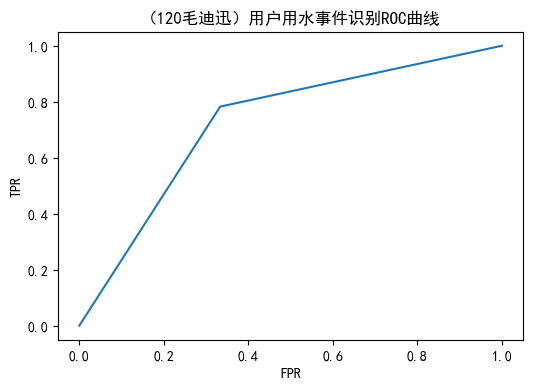

In [34]:
# 绘制roc曲线图
plt.rcParams['font.sans-serif'] = 'SimHei'  # 显示中文
plt.rcParams['axes.unicode_minus'] = False  # 显示负号
fpr, tpr, thresholds = roc_curve(y_pred,y_test)  # 求出TPR和FPR
plt.figure(figsize=(6,4))  # 创建画布
plt.plot(tpr,fpr)      # 绘制曲线
plt.title('（120毛迪迅）用户用水事件识别ROC曲线')          
plt.xlabel('FPR')  # x轴标签
plt.ylabel('TPR')  # y轴标签
plt.savefig('（120毛迪迅）用户用水事件识别ROC曲线.png')  # 保存图片
plt.show()  # 显示图形

In [35]:
import pandas as pd
import numpy as np

# 读取用水事件数据
sj = pd.read_excel('../tmp/sj_final.xlsx', sheet_name='Sheet1')

# 检查数据框的列
print(sj.columns)

# 定义计算连续洗浴判别指标的函数
def calculate_continuous_bathing_indicator(row):
    P = max(0, 0.5 * (row['停顿次数'] - 10))
    A = max(0, 0.2 * (row['总用水量'] - 30))
    D = max(0, 0.005 * (row['总用水时长'] - 900))
    T = max(0, 0.2 * (0.5 - row['用水/总时长']))
    W = max(0, 0.002 * (row['停顿时长波动'] - 1000))
    S = P + A + D + T + W
    return S

# 计算每个用水事件的连续洗浴判别指标
sj['连续洗浴判别指标'] = sj.apply(calculate_continuous_bathing_indicator, axis=1)

# 读取停顿事件数据
stop_df = pd.read_excel('../tmp/sj_final.xlsx', sheet_name='Sheet1')

# 判断是否为连续洗浴事件
def split_continuous_bathing_events(df, stop_df):
    new_events = []
    for idx, row in df.iterrows():
        if row['连续洗浴判别指标'] > 5:
            # 找到停顿时间最长的停顿
            stop_df_event = stop_df[stop_df['事件序号'] == row['事件序号']]
            if not stop_df_event.empty:
                longest_stop = stop_df_event.loc[stop_df_event['平均停顿时长'].idxmax()]
                
                # 分割事件
                event1 = row.copy()
                event2 = row.copy()
                
                event1['事件终止编号'] = longest_stop['事件起始编号']
                event1['事件结束时间'] = pd.to_datetime(row['事件开始时间']) + pd.Timedelta(seconds=event1['总用水时长'])
                event1['总用水时长'] = (event1['事件结束时间'] - pd.to_datetime(row['事件开始时间'])).total_seconds()
                event1['总用水量'] = event1['总用水量'] * (event1['总用水时长'] / row['总用水时长'])
                event1['用水时长'] = event1['总用水时长'] - event1['总停顿时长']
                event1['用水/总时长'] = event1['用水时长'] / event1['总用水时长']
                event1['连续洗浴判别指标'] = calculate_continuous_bathing_indicator(event1)
                
                event2['事件起始编号'] = longest_stop['事件终止编号']
                event2['事件开始时间'] = pd.to_datetime(row['事件结束时间']) - pd.Timedelta(seconds=event2['总用水时长'])
                event2['总用水时长'] = (pd.to_datetime(row['事件结束时间']) - event2['事件开始时间']).total_seconds()
                event2['总用水量'] = event2['总用水量'] * (event2['总用水时长'] / row['总用水时长'])
                event2['用水时长'] = event2['总用水时长'] - event2['总停顿时长']
                event2['用水/总时长'] = event2['用水时长'] / event2['总用水时长']
                event2['连续洗浴判别指标'] = calculate_continuous_bathing_indicator(event2)
                
                new_events.append(event1)
                new_events.append(event2)
            else:
                new_events.append(row)
        else:
            new_events.append(row)
    
    return pd.DataFrame(new_events)

# 应用分割函数
sj_split = split_continuous_bathing_events(sj, stop_df)

# 保存结果
sj_split.to_csv('../tmp/sj_split.csv', index=False)

print('优化后的用水事件数据已保存到 sj_split.csv 文件中。')

Index(['事件序号', '事件起始编号', '事件终止编号', '事件开始时间', '事件结束时间', '洗浴时间点', '总用水时长',
       '总停顿时长', '停顿次数', '平均停顿时长', '用水时长', '用水/总时长', '总用水量', '平均水流量', '水流量波动',
       '停顿时长波动'],
      dtype='object')
优化后的用水事件数据已保存到 sj_split.csv 文件中。


In [36]:
import pandas as pd

# 读取优化后的用水事件数据
sj_split = pd.read_csv('../tmp/sj_split.csv')

# 筛选出连续洗浴事件
continuous_bathing_events = sj_split[sj_split['连续洗浴判别指标'] > 5]

使用的特征: ['洗浴时间点', '总用水时长', '总停顿时长', '平均停顿时长', '停顿次数', '用水时长', '用水/总时长', '总用水量', '平均水流量', '水流量波动', '停顿时长波动', '连续洗浴判别指标']
数据形状: X=(146, 12), y=(146,)
开始训练模型...


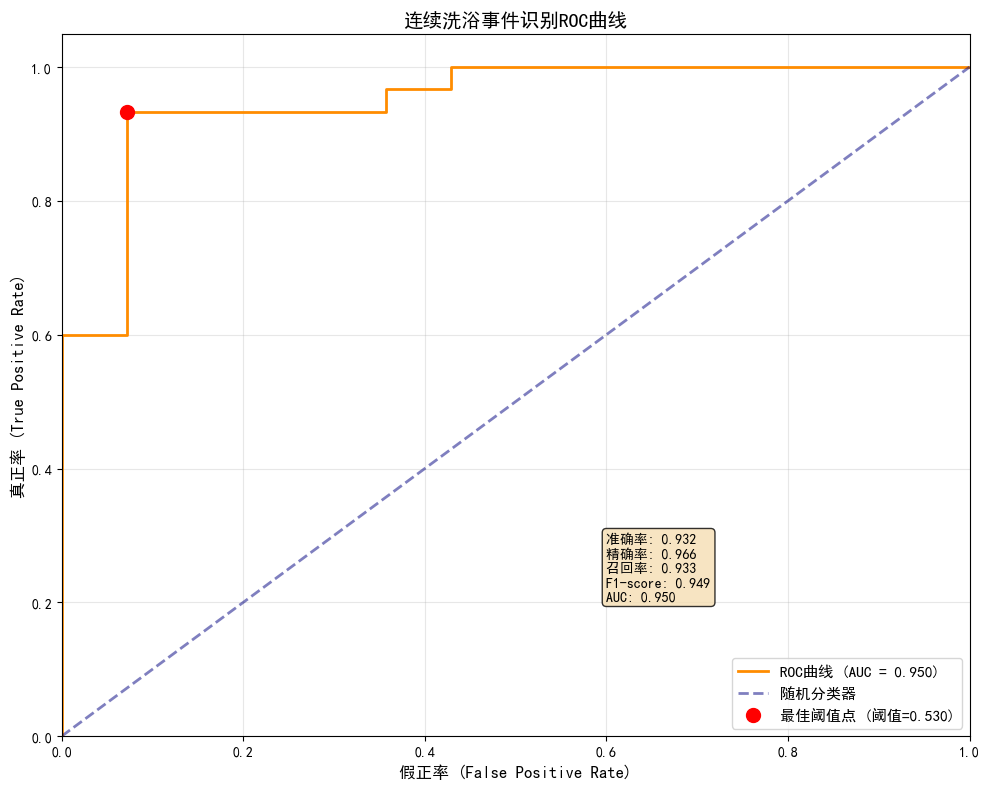

模型评估完成！AUC得分: 0.9500
最佳阈值: 0.5303
模型和标准化器已保存！


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import joblib

# 设置中文字体
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

# 读取分割后的数据
sj_split = pd.read_csv('../tmp/sj_split.csv')

# 读取标签数据（假设您有对应的标签数据）
# 这里需要您提供真实的标签数据路径
try:
    ytrain = pd.read_excel('../data/water_heater_log.xlsx', engine='openpyxl')
    # 通过事件序号合并特征和标签
    merged_data = sj_split.merge(ytrain[['事件序号', '标签']], on='事件序号', how='inner')
    X = merged_data.drop(['标签', '事件序号', '事件起始编号', '事件终止编号', '事件开始时间', '事件结束时间'], axis=1)
    y = merged_data['标签']
except:
    print("无法读取标签数据，使用模拟数据进行演示")
    # 使用模拟标签进行演示
    np.random.seed(42)
    y = np.random.choice([0, 1], size=len(sj_split), p=[0.3, 0.7])

# 选择特征列
feature_columns = ['洗浴时间点', '总用水时长', '总停顿时长', '平均停顿时长', '停顿次数', 
                   '用水时长', '用水/总时长', '总用水量', '平均水流量', '水流量波动', 
                   '停顿时长波动', '连续洗浴判别指标']

# 确保所有特征列都存在
available_features = [col for col in feature_columns if col in X.columns]
X = X[available_features]

print(f"使用的特征: {available_features}")
print(f"数据形状: X={X.shape}, y={y.shape}")

# 划分训练集和测试集
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 数据标准化
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 构建BP神经网络模型
bpnn = MLPClassifier(
    hidden_layer_sizes=(50, 30),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=1000,
    random_state=42,
    early_stopping=True
)

# 训练模型
print("开始训练模型...")
bpnn.fit(x_train_scaled, y_train)

# 预测概率
y_pred_proba = bpnn.predict_proba(x_test_scaled)[:, 1]

# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 绘制ROC曲线
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC曲线 (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='随机分类器', alpha=0.5)

# 标记最佳阈值点
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=10, 
         label=f'最佳阈值点 (阈值={optimal_threshold:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正率 (False Positive Rate)', fontsize=12)
plt.ylabel('真正率 (True Positive Rate)', fontsize=12)
plt.title('连续洗浴事件识别ROC曲线', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)

# 添加性能指标文本框
accuracy = bpnn.score(x_test_scaled, y_test)
y_pred = bpnn.predict(x_test_scaled)
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

textstr = f'准确率: {accuracy:.3f}\n精确率: {precision:.3f}\n召回率: {recall:.3f}\nF1-score: {f1:.3f}\nAUC: {roc_auc:.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.6, 0.2, textstr, fontsize=10, verticalalignment='bottom', bbox=props)

plt.tight_layout()
plt.savefig('../tmp/连续洗浴事件识别ROC曲线.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"模型评估完成！AUC得分: {roc_auc:.4f}")
print(f"最佳阈值: {optimal_threshold:.4f}")

# 保存模型
joblib.dump(bpnn, '../tmp/continuous_bathing_model.m')
joblib.dump(scaler, '../tmp/scaler.m')
print("模型和标准化器已保存！")